<a href="https://colab.research.google.com/github/whosphong/DATA-STRUCTURES-AND-PLATFORMS---UAmath509/blob/main/509_PROJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winter 2025 MATH 509 PROJECT

- Phong Ho
- Michael Zhang
- R.J. Bilak
- Edmond Tuong

------------------------

### Packages

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
import scipy.stats as stats
import matplotlib as mpl
import datetime, nltk, warnings
import matplotlib.cm as cm
from scipy.stats.mstats import winsorize
import itertools
from pathlib import Path
from sklearn.metrics import silhouette_samples, silhouette_score, confusion_matrix
from sklearn import preprocessing, model_selection, metrics, feature_selection
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.svm import SVC
from sklearn import neighbors, linear_model, svm, tree, ensemble
from sklearn.ensemble import AdaBoostClassifier
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from IPython.display import display, HTML
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import sys
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from matplotlib.colors import BoundaryNorm

if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

init_notebook_mode(connected=True)
warnings.filterwarnings("ignore")
plt.rcParams["patch.force_edgecolor"] = True
plt.style.use('fivethirtyeight')
mpl.rc('patch', edgecolor='dimgray', linewidth=1)
%matplotlib inline


In [2]:
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]

sns.set_palette(palette)

# EDA / Preprocessing

-------------------

In [3]:
data = 'https://raw.githubusercontent.com/whosphong/DATA-STRUCTURES-AND-PLATFORMS---UAmath509/refs/heads/main/google_review_ratings.csv'
df = pd.read_csv(data)

In [4]:
df.head(5)

,User,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,...,Category 16,Category 17,Category 18,Category 19,Category 20,Category 21,Category 22,Category 23,Category 24,Unnamed: 25
0,User 1,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.35,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
1,User 2,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.64,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
2,User 3,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
3,User 4,0.0,0.5,3.63,3.63,5.0,2.92,5.0,2.35,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
4,User 5,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN


In [5]:
## Checking types of Data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5454 entries, 0 to 5453
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   User         5454 non-null   object 
 1   Category 1   5454 non-null   float64
 2   Category 2   5454 non-null   float64
 3   Category 3   5454 non-null   float64
 4   Category 4   5454 non-null   float64
 5   Category 5   5454 non-null   float64
 6   Category 6   5454 non-null   float64
 7   Category 7   5454 non-null   float64
 8   Category 8   5454 non-null   float64
 9   Category 9   5454 non-null   float64
 10  Category 10  5454 non-null   float64
 11  Category 11  5454 non-null   float64
 12  Category 12  5454 non-null   float64
 13  Category 13  5454 non-null   float64
 14  Category 14  5454 non-null   float64
 15  Category 15  5454 non-null   float64
 16  Category 16  5454 non-null   float64
 17  Category 17  5454 non-null   float64
 18  Category 18  5454 non-null   float64
 19  Catego

In [6]:
df.describe()

,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10,...,Category 16,Category 17,Category 18,Category 19,Category 20,Category 21,Category 22,Category 23,Category 24,Unnamed: 25
count,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,...,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,0.0
mean,1.455746,2.320048,2.489059,2.797103,2.958904,2.893423,3.351476,2.541177,3.126542,2.832695,...,1.192710,0.949349,0.822525,0.969250,0.999626,0.965275,1.749345,1.531051,1.560570,NaN
std,0.827732,1.421576,1.247503,1.309188,1.338785,1.282101,1.413291,1.111398,1.356774,1.307299,...,1.107176,0.973628,0.948015,1.202883,1.193129,0.928326,1.597816,1.316180,1.171784,NaN
min,0.000000,0.000000,0.000000,0.830000,1.120000,1.110000,1.120000,0.860000,0.840000,0.810000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.920000,1.360000,1.540000,1.730000,1.770000,1.790000,1.930000,1.620000,1.800000,1.640000,...,0.690000,0.580000,0.530000,0.520000,0.540000,0.570000,0.740000,0.790000,0.880000,NaN
50%,1.340000,1.910000,2.060000,2.460000,2.670000,2.680000,3.230000,2.170000,2.800000,2.680000,...,0.800000,0.740000,0.690000,0.690000,0.690000,0.760000,1.030000,1.070000,1.290000,NaN
75%,1.810000,2.687500,2.740000,4.097500,4.310000,3.837500,5.000000,3.190000,5.000000,3.527500,...,1.160000,0.910000,0.840000,0.860000,0.860000,1.000000,2.070000,1.560000,1.660000,NaN
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,NaN


In [7]:
df.drop(columns=['User', 'Unnamed: 25'], inplace=True)

In [8]:
df = df.rename(columns = {
    "Category 1": "churches", 
    "Category 2": "resorts", 
    "Category 3": "beaches", 
    "Category 4": "parks", 
    "Category 5": "theatres",
    "Category 6": "museums", 
    "Category 7": "malls", 
    "Category 8": "zoos", 
    "Category 9": "restaurants", 
    "Category 10": "pubs", 
    "Category 11": "services", 
    "Category 12": "pizzerias", 
    "Category 13": "hotels", 
    "Category 14": "refreshments", 
    "Category 15": "galleries", 
    "Category 16": "clubs", 
    "Category 17": "pools", 
    "Category 18": "gyms", 
    "Category 19": "bakeries", 
    "Category 20": "spas", 
    "Category 21": "cafes", 
    "Category 22": "panorama", 
    "Category 23": "monuments", 
    "Category 24": "gardens"
}).copy()


In [10]:
df.head()

,churches,resorts,beaches,parks,theatres,museums,malls,zoos,restaurants,pubs,...,galleries,clubs,pools,gyms,bakeries,spas,cafes,panorama,monuments,gardens
0,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.35,2.33,2.64,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.64,2.33,2.65,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,2.64,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0
3,0.0,0.5,3.63,3.63,5.0,2.92,5.0,2.35,2.33,2.64,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,2.64,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0


In [9]:
df.describe()

,churches,resorts,beaches,parks,theatres,museums,malls,zoos,restaurants,pubs,...,galleries,clubs,pools,gyms,bakeries,spas,cafes,panorama,monuments,gardens
count,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,...,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000
mean,1.455746,2.320048,2.489059,2.797103,2.958904,2.893423,3.351476,2.541177,3.126542,2.832695,...,2.206140,1.192710,0.949349,0.822525,0.969250,0.999626,0.965275,1.749345,1.531051,1.560570
std,0.827732,1.421576,1.247503,1.309188,1.338785,1.282101,1.413291,1.111398,1.356774,1.307299,...,1.715848,1.107176,0.973628,0.948015,1.202883,1.193129,0.928326,1.597816,1.316180,1.171784
min,0.000000,0.000000,0.000000,0.830000,1.120000,1.110000,1.120000,0.860000,0.840000,0.810000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.920000,1.360000,1.540000,1.730000,1.770000,1.790000,1.930000,1.620000,1.800000,1.640000,...,0.860000,0.690000,0.580000,0.530000,0.520000,0.540000,0.570000,0.740000,0.790000,0.880000
50%,1.340000,1.910000,2.060000,2.460000,2.670000,2.680000,3.230000,2.170000,2.800000,2.680000,...,1.330000,0.800000,0.740000,0.690000,0.690000,0.690000,0.760000,1.030000,1.070000,1.290000
75%,1.810000,2.687500,2.740000,4.097500,4.310000,3.837500,5.000000,3.190000,5.000000,3.527500,...,4.440000,1.160000,0.910000,0.840000,0.860000,0.860000,1.000000,2.070000,1.560000,1.660000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Relative Plot Of Some Selected Features: A Data Subset


<Figure size 1500x1000 with 0 Axes>

<Figure size 800x550 with 0 Axes>

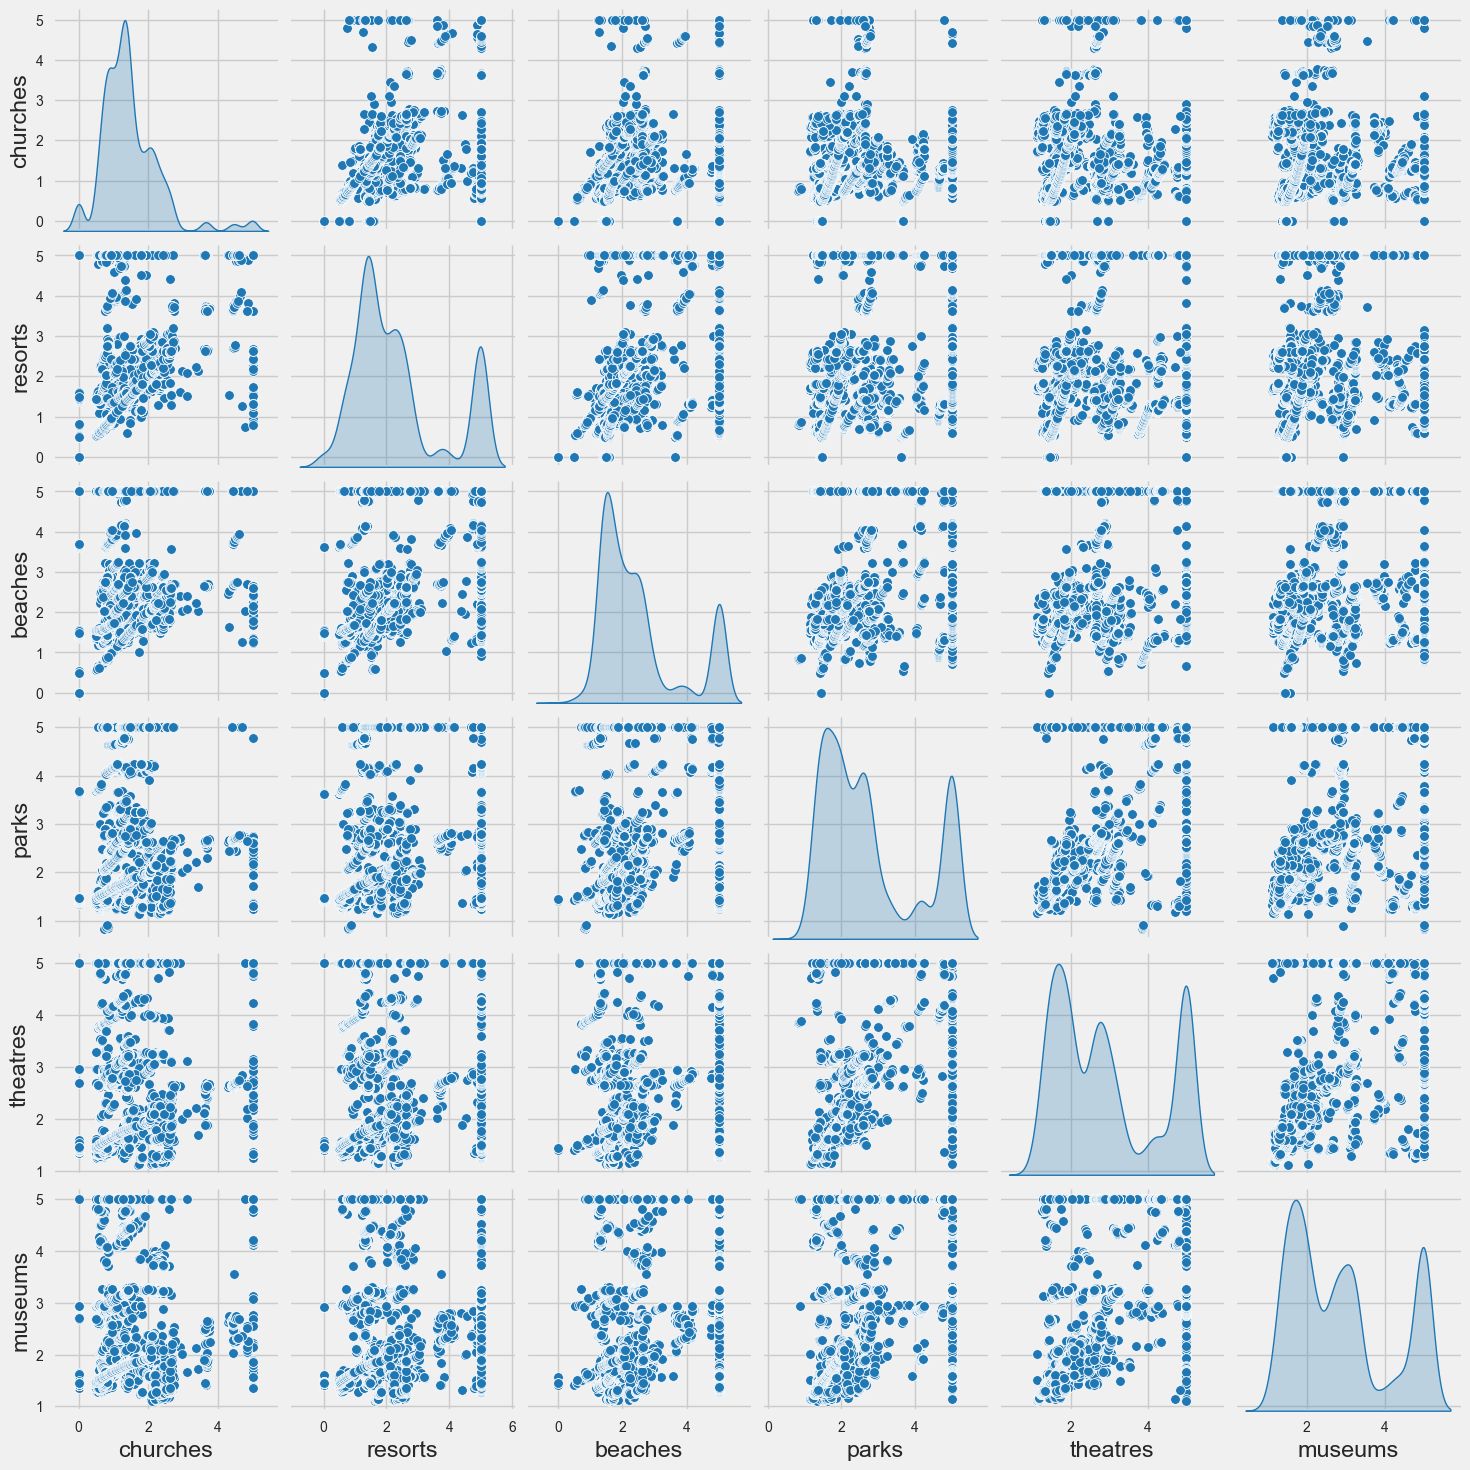

In [ ]:

To_Plot = ["churches", "resorts", "beaches", "parks", "theatres", "museums"]

print("Relative Plot Of Some Selected Features: A Data Subset")

plt.figure()
sns.pairplot(df[To_Plot], diag_kind="kde")
plt.show()


In [10]:
df.isna().sum() ## None


churches        0
resorts         0
beaches         0
parks           0
theatres        0
museums         0
malls           0
zoos            0
restaurants     0
pubs            0
services        0
pizzerias       0
hotels          0
refreshments    0
galleries       0
clubs           0
pools           0
gyms            0
bakeries        0
spas            0
cafes           0
panorama        0
monuments       0
gardens         0
dtype: int64

In [11]:
dup_df = df[df.duplicated(keep=False)] ## Indicates 2 == 4, 670 == 674, 1338 == 1346
dup_df


,churches,resorts,beaches,parks,theatres,museums,malls,zoos,restaurants,pubs,...,galleries,clubs,pools,gyms,bakeries,spas,cafes,panorama,monuments,gardens
2,0.00,0.0,3.63,3.63,5.00,2.92,5.00,2.64,2.33,2.64,...,1.74,0.59,0.5,0.0,0.50,0.0,0.0,0.00,0.00,0.00
4,0.00,0.0,3.63,3.63,5.00,2.92,5.00,2.64,2.33,2.64,...,1.74,0.59,0.5,0.0,0.50,0.0,0.0,0.00,0.00,0.00
670,0.00,0.0,1.45,1.43,1.42,1.43,1.48,1.48,2.72,2.73,...,5.00,0.81,0.8,5.0,0.92,0.0,0.0,0.00,0.00,0.00
674,0.00,0.0,1.45,1.43,1.42,1.43,1.48,1.48,2.72,2.73,...,5.00,0.81,0.8,5.0,0.92,0.0,0.0,0.00,0.00,0.00
1338,1.06,1.1,5.00,3.28,5.00,5.00,5.00,1.84,1.81,5.00,...,1.77,1.80,0.0,0.0,0.00,0.0,0.0,1.05,1.03,1.04
1346,1.06,1.1,5.00,3.28,5.00,5.00,5.00,1.84,1.81,5.00,...,1.77,1.80,0.0,0.0,0.00,0.0,0.0,1.05,1.03,1.04


In [ ]:
df.drop_duplicates(inplace=True)

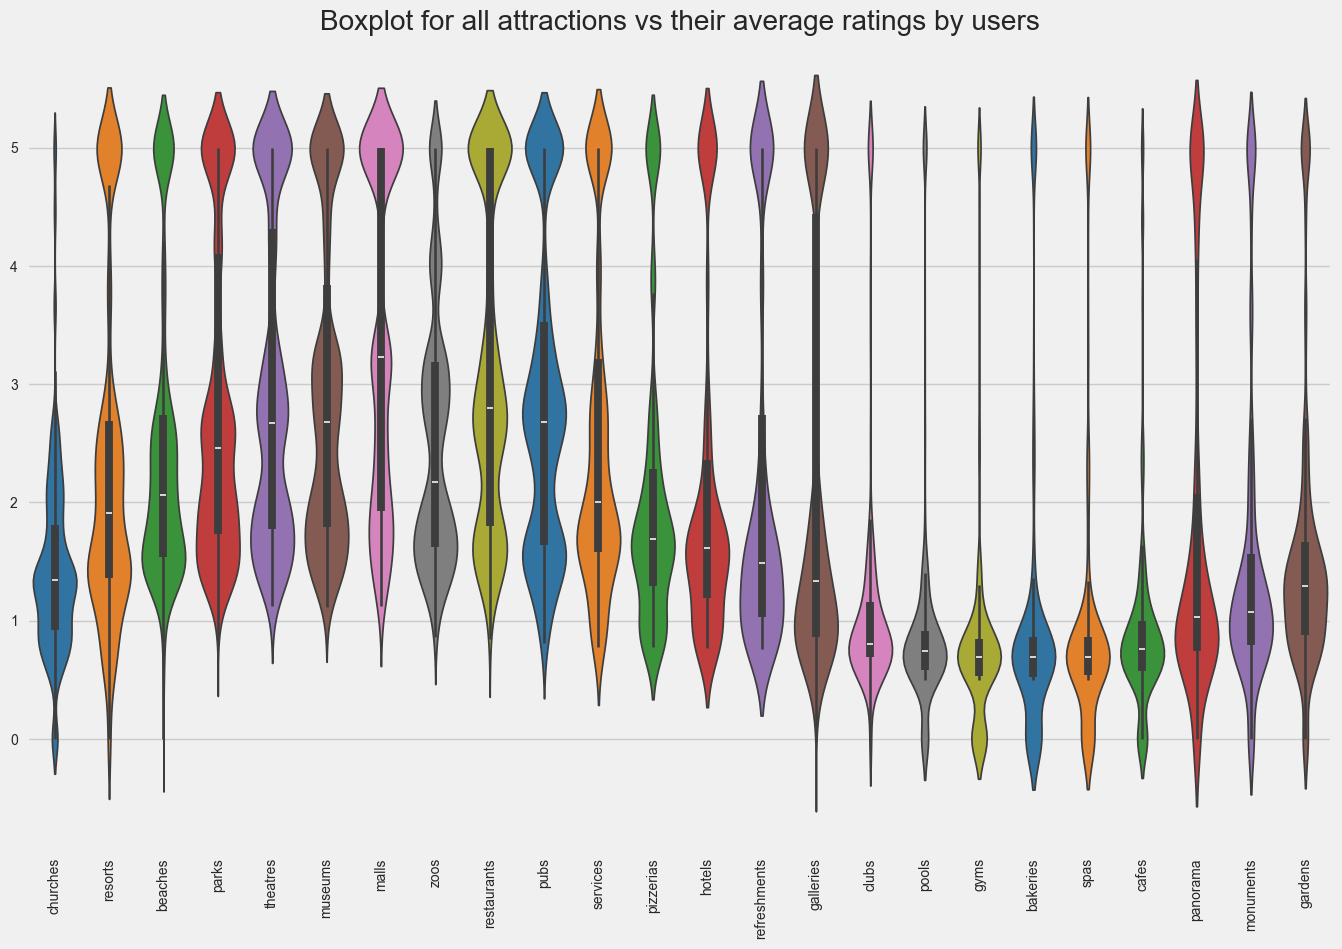

In [14]:
plt.figure(figsize=(15, 10))
sns.violinplot(data=df, palette=palette)
plt.xticks(rotation=90)
plt.title('Boxplot for all attractions vs their average ratings by users')
plt.show()


In [16]:
# Q1 = df.quantile(0.25)
# Q3 = df.quantile(0.75)
# IQR = Q3 - Q1
# print(IQR)

# #df = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)] ## Removing Outliers

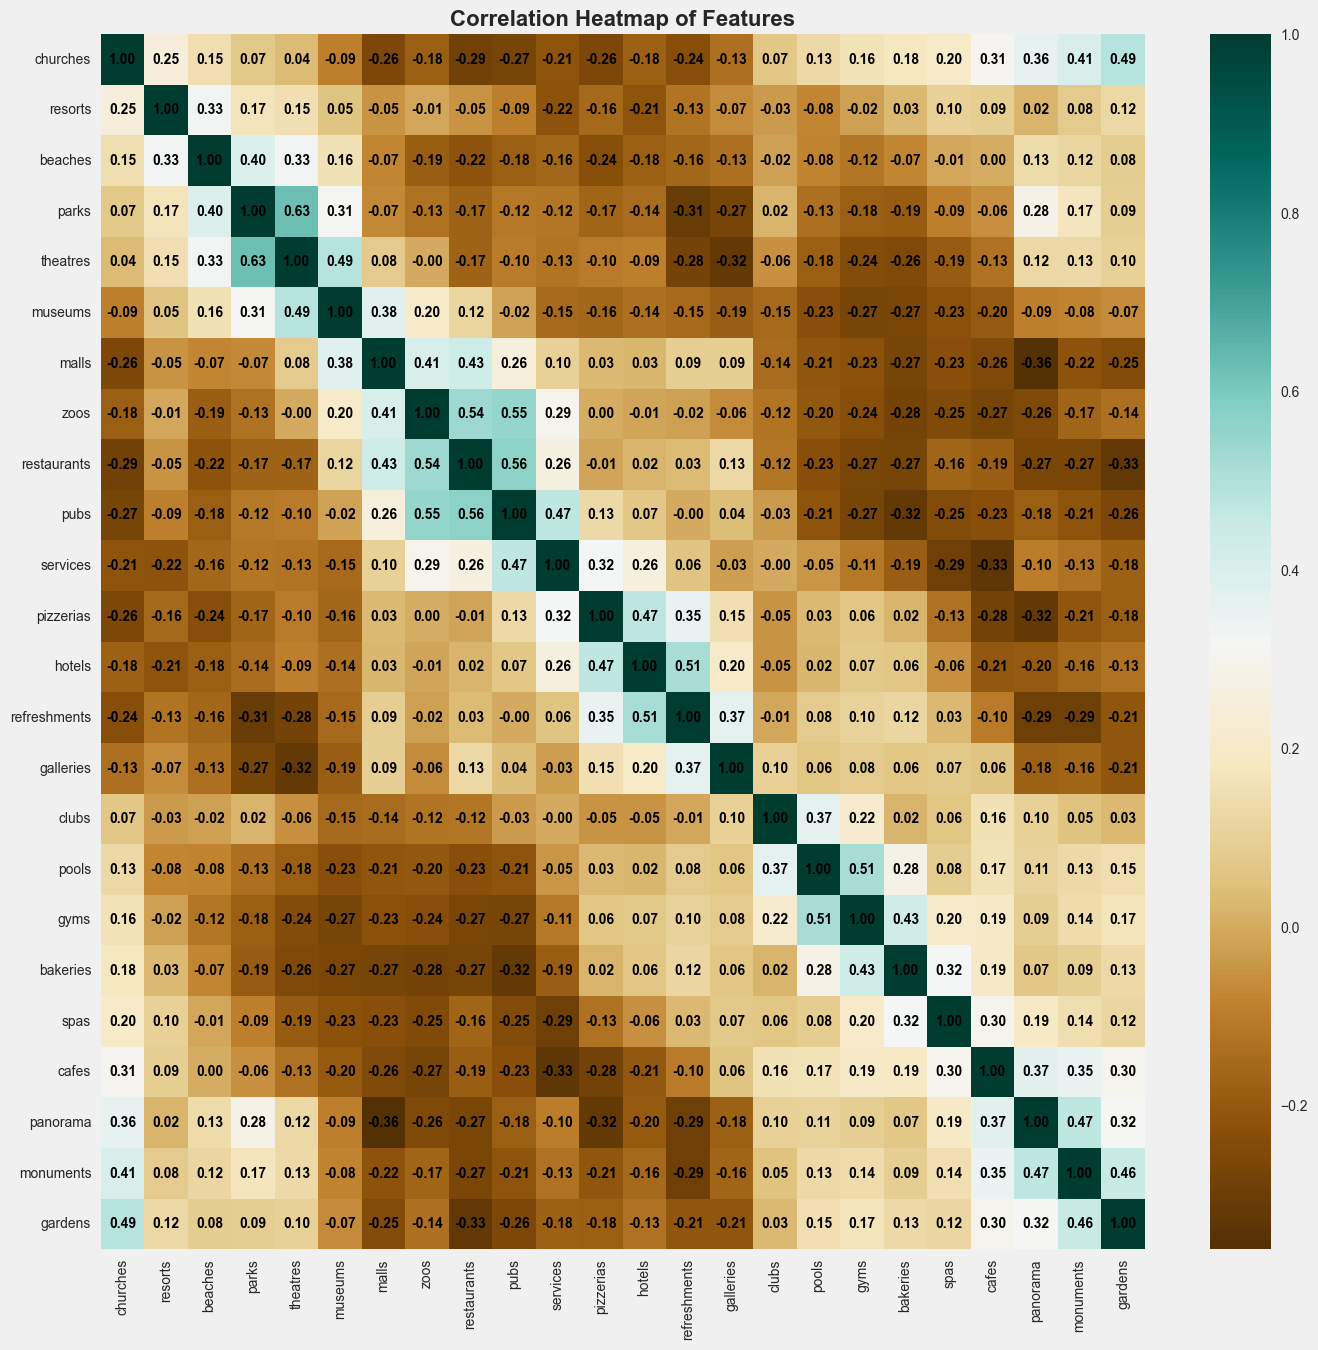

In [15]:
plt.figure(figsize=(15, 15))
c = df.corr()
sns.heatmap(c, cmap="BrBG", annot=True, fmt=".2f", annot_kws={"size": 10, "weight": "bold", "color": "black"})
plt.title("Correlation Heatmap of Features", fontsize=16, weight="bold")
plt.show()

In [12]:
c[c==1] = 0
maxcorrs = pd.DataFrame()
maxcorrs["Max Correlation"] = np.max(abs(c), axis=0)
maxcorrs["With"] = np.argmax(abs(c), axis=0)+1
maxcorrs

# Correlations seem not high enough to justify removing any

,Max Correlation,With
churches,0.489249,24
resorts,0.325429,3
beaches,0.396694,4
parks,0.626787,5
theatres,0.626787,4
museums,0.489528,5
malls,0.432183,9
zoos,0.551613,10
restaurants,0.564442,10
pubs,0.564442,9


In [17]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
scaled_ds = pd.DataFrame(df_scaled, columns=df.columns)

In [18]:
scaled_ds.head(5)

,churches,resorts,beaches,parks,theatres,museums,malls,zoos,restaurants,pubs,...,galleries,clubs,pools,gyms,bakeries,spas,cafes,panorama,monuments,gardens
0,-1.760164,-1.633391,0.915264,0.651441,1.525493,0.020829,1.166893,-0.172279,-0.587392,-0.147147,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573
1,-1.760164,-1.633391,0.915264,0.651441,1.525493,0.020829,1.166893,0.088638,-0.587392,-0.139497,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573
2,-1.760164,-1.633391,0.915264,0.636165,1.525493,0.020829,1.166893,0.088638,-0.587392,-0.147147,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573
3,-1.760164,-1.281537,0.915264,0.636165,1.525493,0.020829,1.166893,-0.172279,-0.587392,-0.147147,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573
4,-1.760164,-1.633391,0.915264,0.636165,1.525493,0.020829,1.166893,0.079640,-0.587392,-0.139497,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573


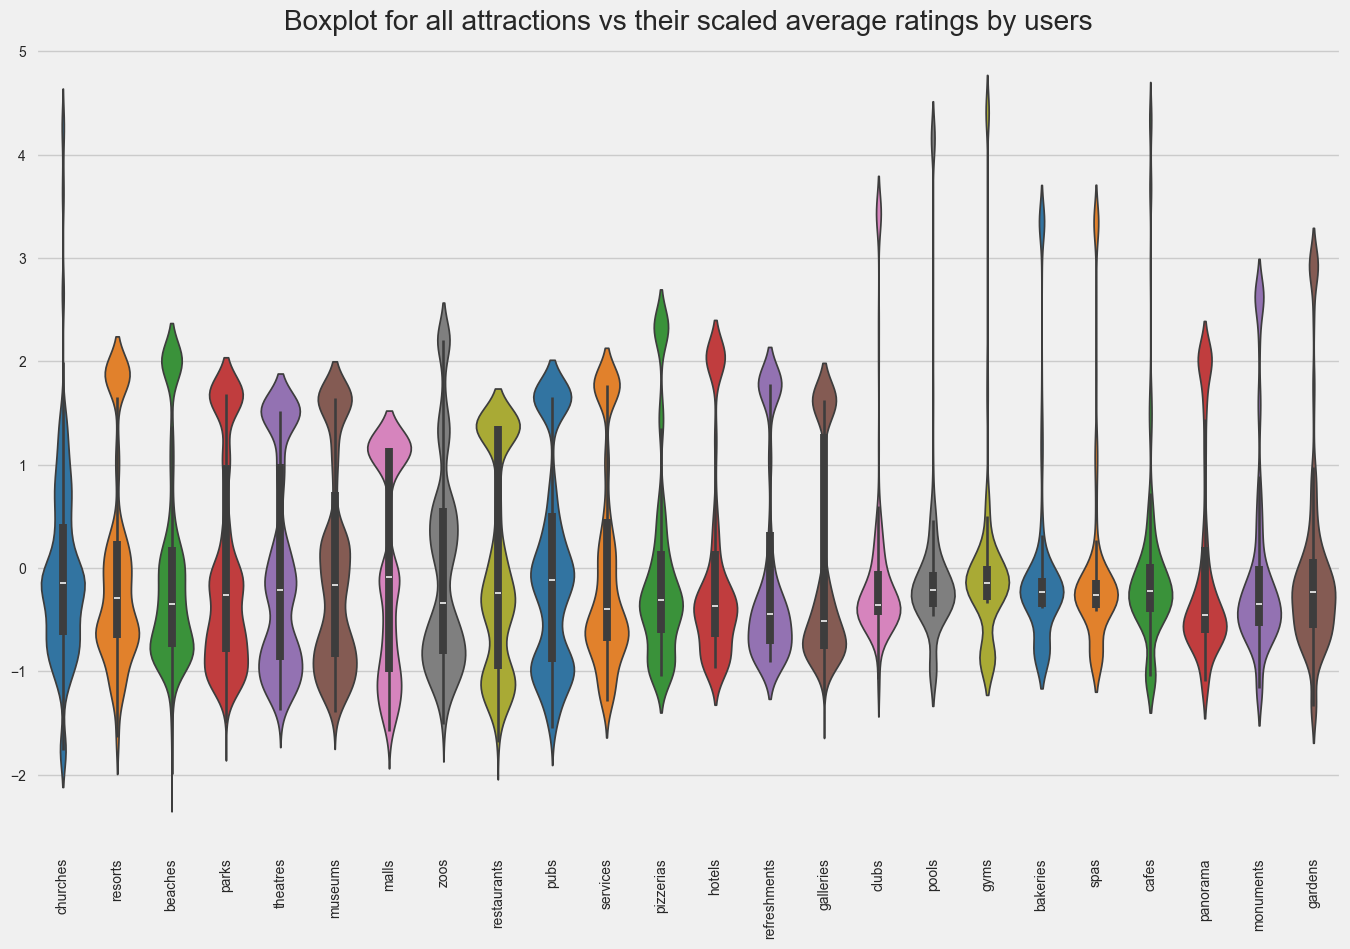

In [25]:
plt.figure(figsize=(15, 10))
sns.violinplot(data=scaled_ds, palette=palette)
plt.xticks(rotation=90)
plt.title('Boxplot for all attractions vs their scaled average ratings by users')
plt.show()


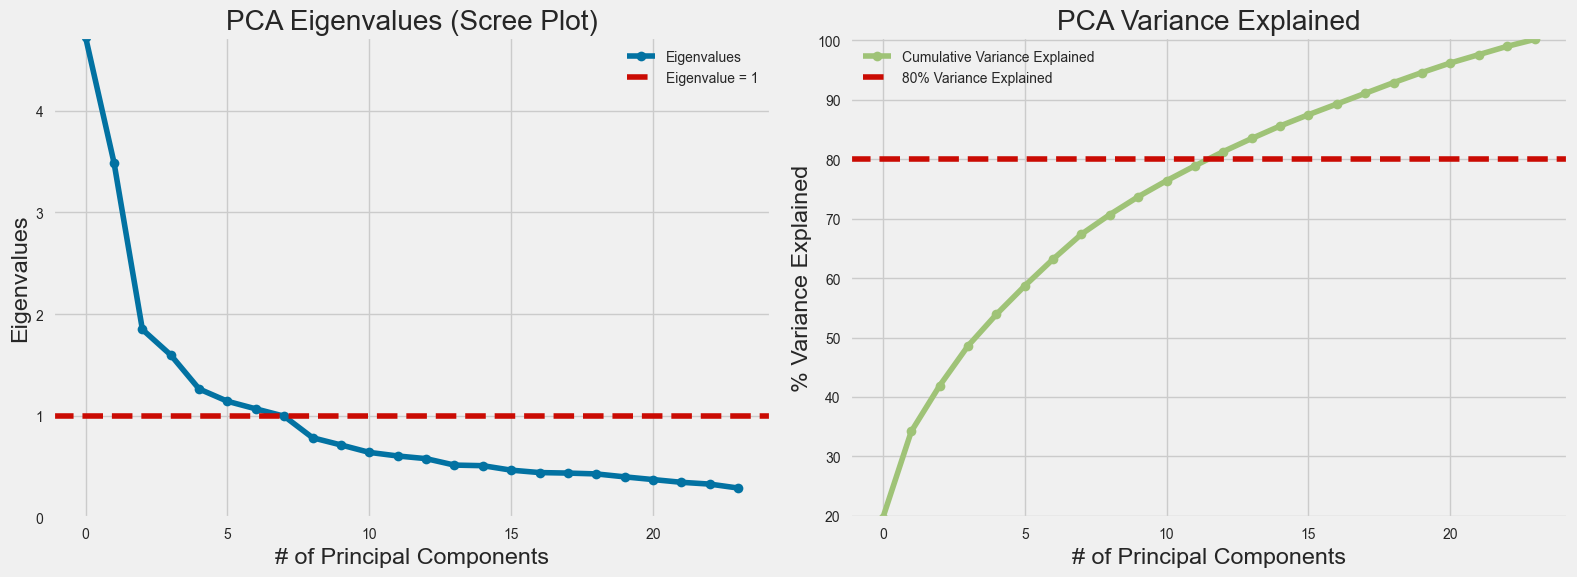

In [ ]:


# Fit PCA model
pca = PCA(n_components=len(scaled_ds.columns))  # Number of components equals the number of features
pca.fit(scaled_ds)

# Create a 1x2 grid of subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# --- Eigenvalue Plot (Scree Plot) ---
ax[0].set_ylabel('Eigenvalues')
ax[0].set_xlabel('# of Principal Components')
ax[0].set_title('PCA Eigenvalues (Scree Plot)')
ax[0].set_ylim(0, max(pca.explained_variance_))  # Set the y-axis limit to the max eigenvalue
ax[0].plot(pca.explained_variance_, marker='o', linestyle='-', color='b', label='Eigenvalues')
ax[0].axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1')  # Threshold line
ax[0].legend(loc='best')

# --- Variance Explained Plot ---
variance = pca.explained_variance_ratio_  # Calculate variance ratios
var = np.cumsum(np.round(variance, decimals=3) * 100)  # Cumulative variance explained in percentage

ax[1].set_ylabel('% Variance Explained')
ax[1].set_xlabel('# of Principal Components')
ax[1].set_title('PCA Variance Explained')
ax[1].set_ylim(min(var), 100.5)  # Set the y-axis from the min variance to 100%
ax[1].plot(var, marker='o', linestyle='-', color='g', label='Cumulative Variance Explained')
ax[1].axhline(y=80, color='r', linestyle='--', label='80% Variance Explained')  # Threshold line
ax[1].legend(loc='best')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


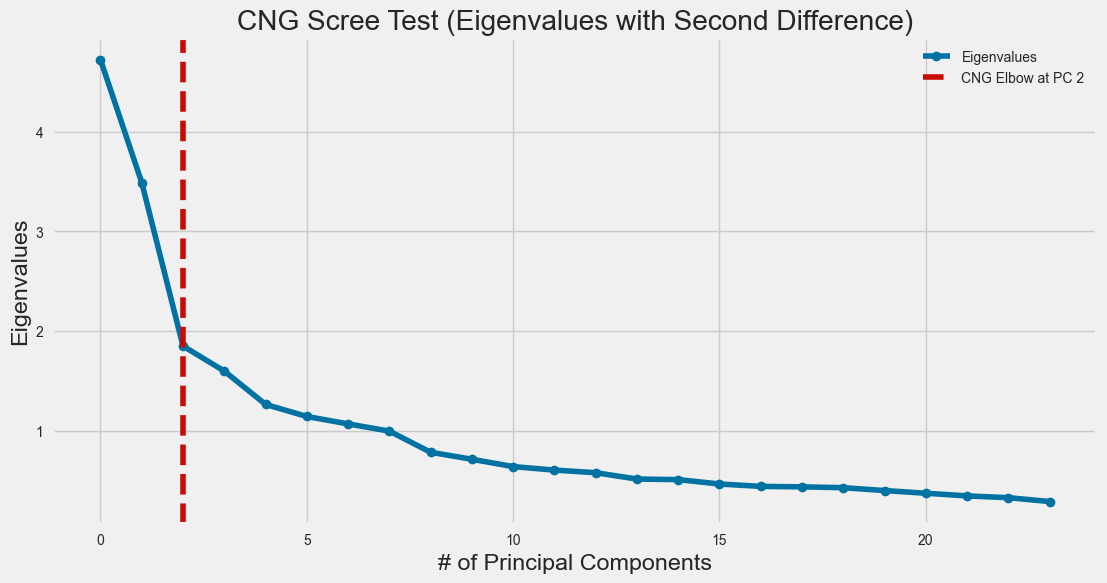

Optimal number of principal components (CNG elbow point): PC2


In [44]:
# Fit PCA model
pca = PCA(n_components=len(scaled_ds.columns))  # Number of components equals the number of features
pca.fit(scaled_ds)

# Get the eigenvalues (explained variance)
eigenvalues = pca.explained_variance_

# Calculate the first differences (change between consecutive eigenvalues)
first_diff = np.diff(eigenvalues)

# Calculate the second differences (change in first differences)
second_diff = np.diff(first_diff)

# Find the index of the largest second difference (this is our CNG elbow point)
cng_elbow_index = np.argmax(second_diff) + 1  # +1 because np.diff reduces length by 1

# Plotting the results
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the eigenvalues (Scree plot)
ax.plot(eigenvalues, marker='o', linestyle='-', color='b', label='Eigenvalues')

# Add the CNG elbow line
ax.axvline(x=cng_elbow_index, color='r', linestyle='--', label=f'CNG Elbow at PC {cng_elbow_index}')

# Set labels and title
ax.set_ylabel('Eigenvalues')
ax.set_xlabel('# of Principal Components')
ax.set_title('CNG Scree Test (Eigenvalues with Second Difference)')

# Show the legend
ax.legend(loc='best')

plt.show()

# Print the optimal number of components based on CNG scree test
print(f"Optimal number of principal components (CNG elbow point): PC{cng_elbow_index}")

https://sanchitamangale12.medium.com/scree-plot-733ed72c8608

In [73]:
pca = PCA(n_components=7)
scaled_ds_9D = pca.fit_transform(scaled_ds)
mat = pd.DataFrame(scaled_ds_9D)
mat2 = pd.DataFrame(scaled_ds_9D)

In [102]:
pca = PCA(n_components=2)
scaled_ds_9D = pca.fit_transform(scaled_ds)
mat = pd.DataFrame(scaled_ds_9D, columns=["PC1", "PC2"])
mat2 = pd.DataFrame(scaled_ds_9D)

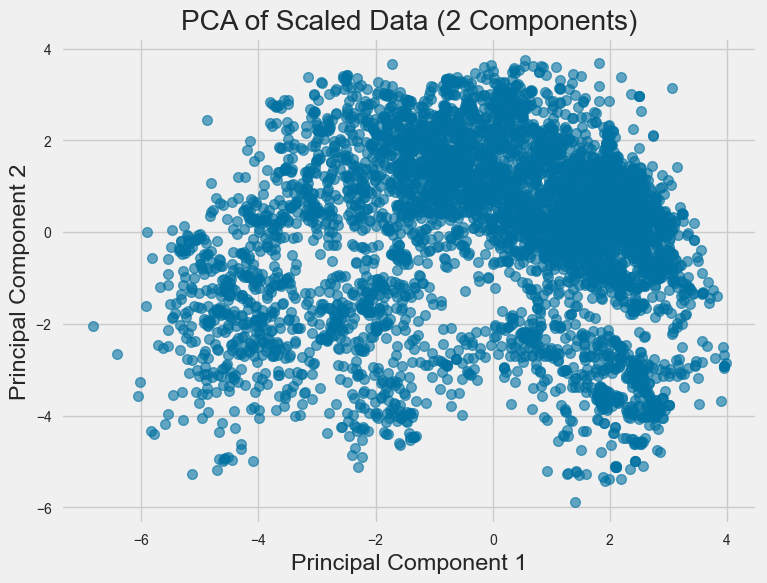

In [103]:
# --- Scatter Plot of PCA Components ---
plt.figure(figsize=(8, 6))

# Plot the points with PC1 and PC2
plt.scatter(mat['PC1'], mat['PC2'], color='b', alpha=0.6)

# Add labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Scaled Data (2 Components)')

# Optionally, add gridlines for better readability
plt.grid(True)

# Show the plot
plt.show()

Elbow Method to determine the number of clusters to be formed:


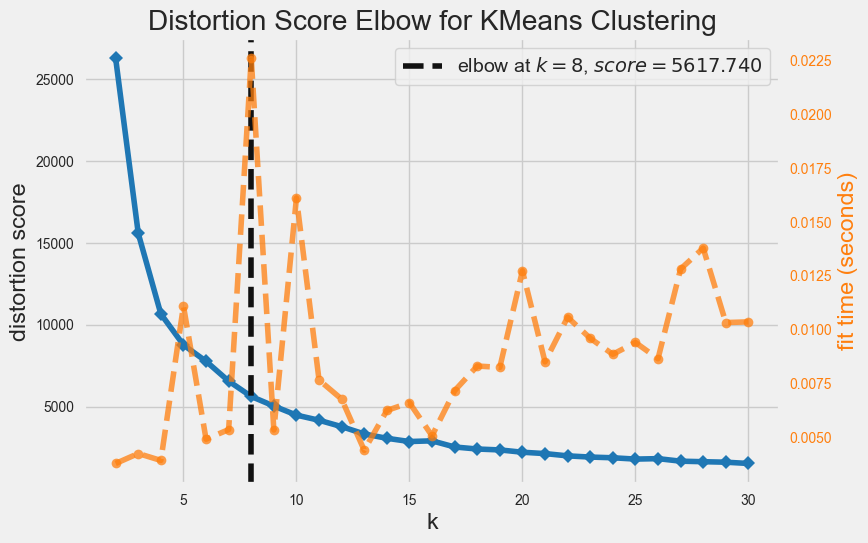

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [104]:
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=30)
Elbow_M.fit(mat)
Elbow_M.show()

In [105]:
best_score = -1
best_n_clusters = 2

for n_clusters in range(2, 11):  # Try clusters from 2 to 10
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(mat)  # X is your dataset
    score = silhouette_score(mat, kmeans.labels_)
    print(f"For n_clusters = {n_clusters}, the average silhouette score is: {score}")

    if score > best_score:
        best_score = score
        best_n_clusters = n_clusters

print(f"The best number of clusters is: {best_n_clusters} with a silhouette score of {best_score}")

For n_clusters = 2, the average silhouette score is: 0.4039116461407995
For n_clusters = 3, the average silhouette score is: 0.4273841454028545
For n_clusters = 4, the average silhouette score is: 0.4418834674105732
For n_clusters = 5, the average silhouette score is: 0.39810392002211453
For n_clusters = 6, the average silhouette score is: 0.34215649141930177
For n_clusters = 7, the average silhouette score is: 0.3534143147881738
For n_clusters = 8, the average silhouette score is: 0.3606396752159141
For n_clusters = 9, the average silhouette score is: 0.3688970186982749
For n_clusters = 10, the average silhouette score is: 0.36781088994824784
The best number of clusters is: 4 with a silhouette score of 0.4418834674105732


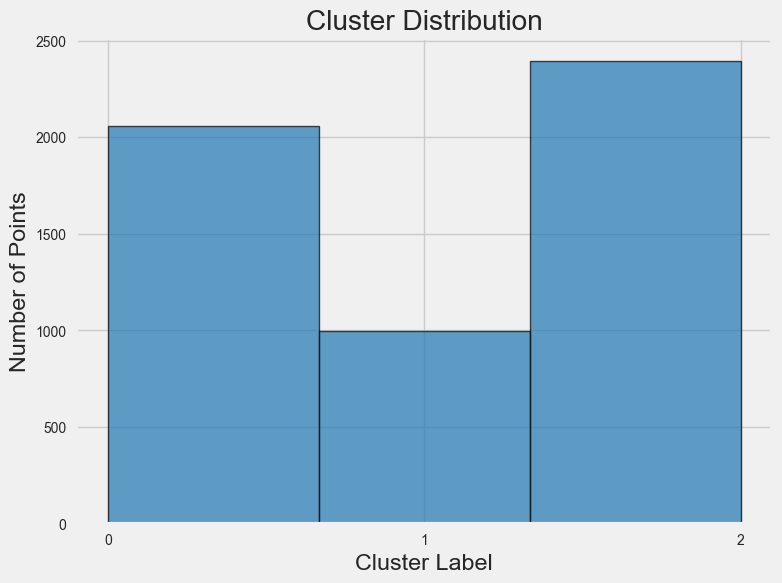

In [106]:
# Fit the KMeans model and assign cluster labels
kmeans = KMeans(init='k-means++', n_clusters=3, n_init=30, random_state=42)
kmeans.fit(mat)
clusters = kmeans.predict(mat)

# Add the cluster labels to the DataFrame
mat['cluster'] = pd.Series(clusters)

# Plot the histogram of the cluster labels
plt.figure(figsize=(8, 6))
plt.hist(mat['cluster'], bins=len(set(clusters)), edgecolor='black', alpha=0.7)
plt.title('Cluster Distribution')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Points')
plt.xticks(range(0, len(set(clusters))))  # Ensure each cluster label is shown on x-axis
plt.show()

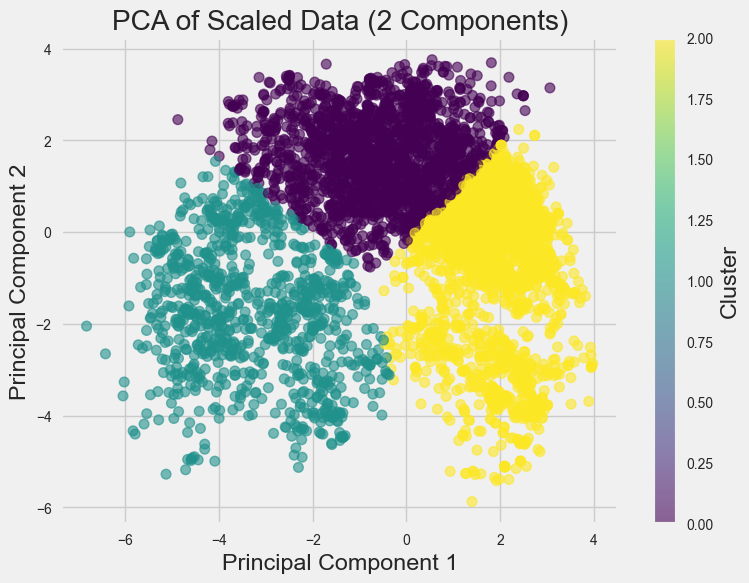

In [108]:
plt.figure(figsize=(8, 6))

# Plot the points with PC1 and PC2, using 'c' for color coding based on the cluster
plt.scatter(mat['PC1'], mat['PC2'], c=mat['cluster'], cmap='viridis', alpha=0.6)

# Add labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Scaled Data (2 Components)')

# Optionally, add gridlines for better readability
plt.grid(True)

# Show the plot
plt.colorbar(label='Cluster')  # Optional: Adds a color bar to indicate cluster labels
plt.show()

In [110]:
scaled_ds['cluster'] = clusters  # Add the cluster labels as a new column
df['cluster'] = clusters  # Add the cluster labels as a new column

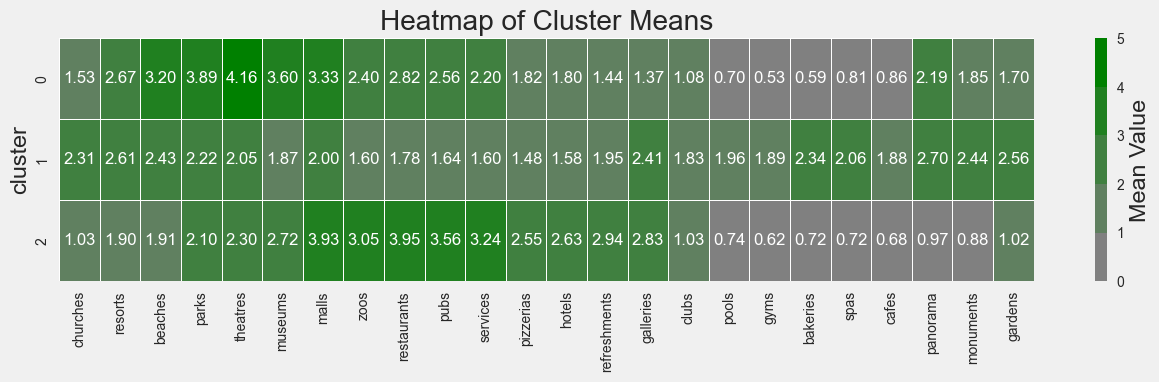

In [ ]:
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap

# Group by cluster and calculate the mean of each feature for each cluster
grouped_df = df.groupby('cluster').mean()

# Create a custom colormap from white to blue
white_blue_cmap = LinearSegmentedColormap.from_list("grey_to_blue", ["grey", "green"])

# Define the color boundaries for each range (adjust based on your data)
boundaries = [0, 1, 2, 3, 4, 5]  # Adjust this list based on your actual feature values
norm = BoundaryNorm(boundaries, white_blue_cmap.N)

# Create the heatmap with adjusted figure size
plt.figure(figsize=(14, 3))  # Adjust the figure size to make it more square-like

# Create the heatmap
sns.heatmap(grouped_df, cmap=white_blue_cmap, norm=norm, annot=True, fmt='.2f', linewidths=0.5, 
                 annot_kws={"size": 12}, cbar_kws={'label': 'Mean Value'})  # Adjust annotation size

# Display the heatmap
plt.title('Heatmap of Cluster Means')
plt.show()

In [ ]:
pca = PCA(n_components=2)
scaled_ds_2D = pca.fit_transform(scaled_ds)

# Step 2: Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)  # You may need to adjust eps and min_samples based on your dataset
dbscan_labels = dbscan.fit_predict(scaled_ds_2D)

# Add DBSCAN labels to the matrix
mat = pd.DataFrame(scaled_ds_2D, columns=['PC1', 'PC2'])
mat['dbscan_cluster'] = dbscan_labels  # Add cluster labels as a new column


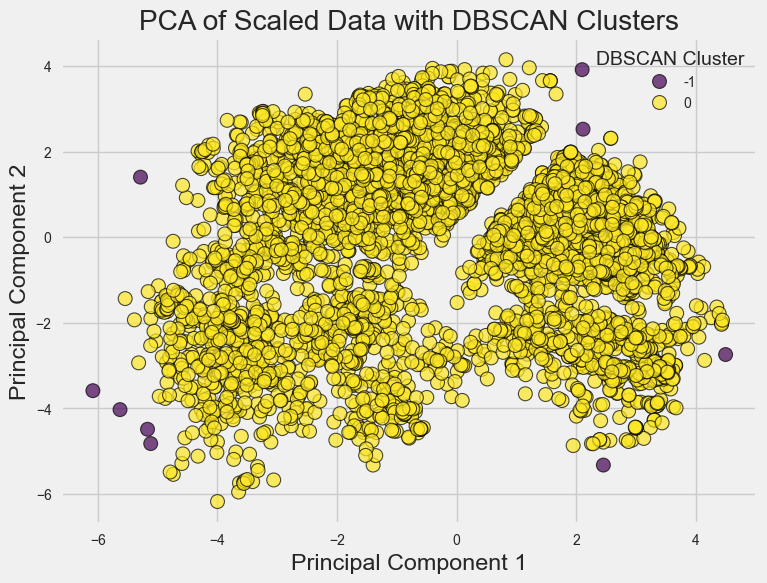

Unique DBSCAN clusters: [-1  0]


In [130]:
# Step 3: Plot the results (PCA components colored by DBSCAN clusters)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='dbscan_cluster', palette='viridis', data=mat, s=100, alpha=0.7, edgecolor='black')

# Customize plot labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Scaled Data with DBSCAN Clusters')

# Display the plot
plt.legend(title='DBSCAN Cluster')
plt.show()

# Optionally: Print the number of clusters found by DBSCAN
unique_clusters = np.unique(dbscan_labels)
print(f"Unique DBSCAN clusters: {unique_clusters}")

In [131]:
df['dbscan_cluster'] = dbscan_labels  # Add cluster labels as a new column

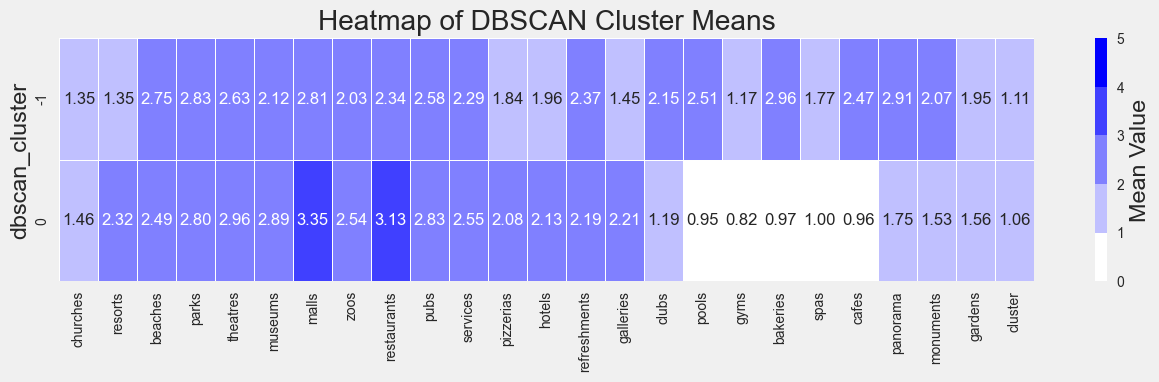

In [133]:
# Group by DBSCAN cluster and calculate the mean of each feature for each cluster
grouped_df = df.groupby('dbscan_cluster').mean()

# Create a custom colormap from white to blue
white_blue_cmap = LinearSegmentedColormap.from_list("white_to_blue", ["white", "blue"])

# Define the color boundaries for each range (adjust this based on your data)
boundaries = [0, 1, 2, 3, 4, 5]  # Adjust this list based on the actual feature values
norm = BoundaryNorm(boundaries, white_blue_cmap.N)

# Create the heatmap with adjusted figure size
plt.figure(figsize=(14, 3))  # Adjust the figure size to make it more square-like

# Create the heatmap
sns.heatmap(grouped_df, cmap=white_blue_cmap, norm=norm, annot=True, fmt='.2f', linewidths=0.5, 
            annot_kws={"size": 12}, cbar_kws={'label': 'Mean Value'})  # Adjust annotation size

# Display the heatmap
plt.title('Heatmap of DBSCAN Cluster Means')
plt.show()